In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
%matplotlib inline

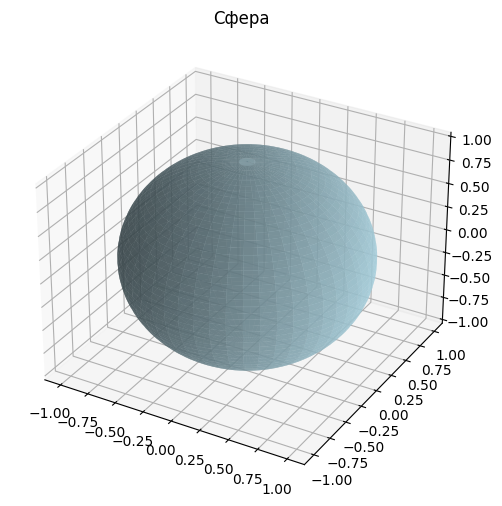

In [2]:
theta = np.linspace(0, 2*np.pi, 100)
phi = np.linspace(0, np.pi, 100)
theta, phi = np.meshgrid(theta, phi)

x = np.sin(phi) * np.cos(theta)
y = np.sin(phi) * np.sin(theta)
z = np.cos(phi)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, color='lightblue', alpha=0.7)
ax.set_title('Сфера')
plt.show()

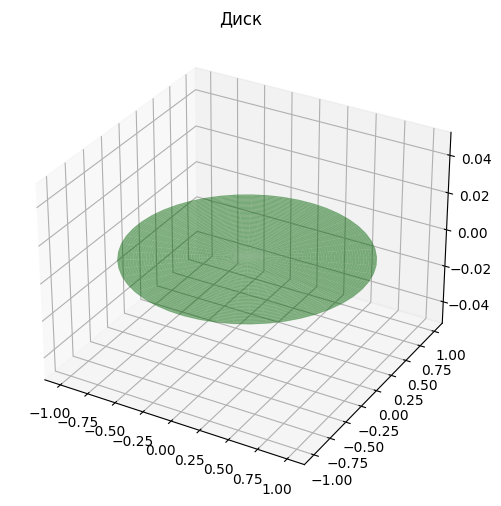

In [4]:
r = np.linspace(0, 1, 50)
theta = np.linspace(0, 2*np.pi, 50)
R, Theta = np.meshgrid(r, theta)

x = R * np.cos(Theta)
y = R * np.sin(Theta)
z = np.zeros_like(x)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, color='green', alpha=0.5)
ax.set_title('Диск')
plt.show()

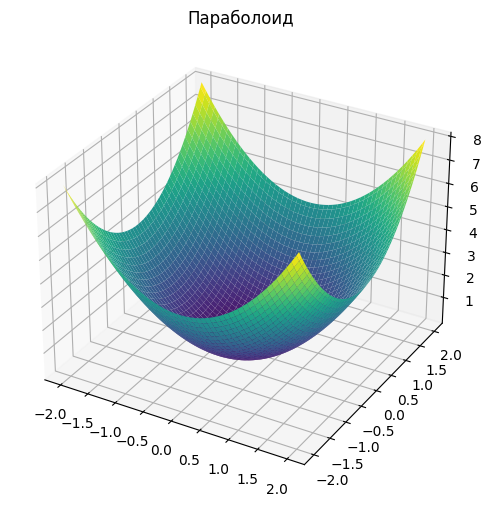

In [5]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_title('Параболоид')
plt.show()

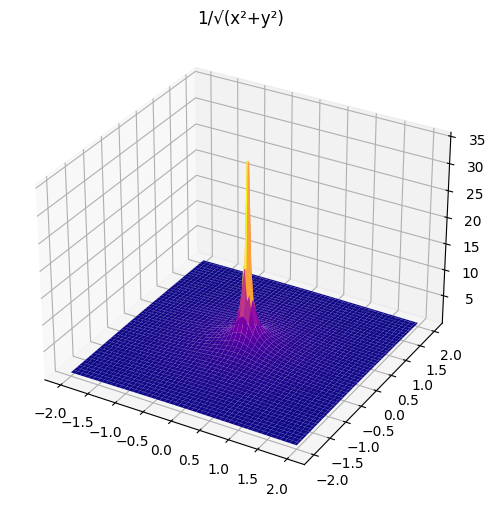

In [7]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)
Z = 1 / np.sqrt(X**2 + Y**2)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='plasma')
ax.set_title('1/√(x²+y²)')
plt.show()

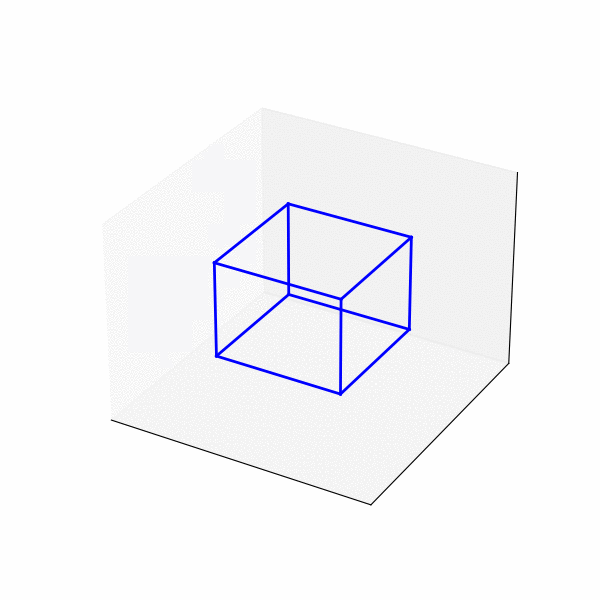

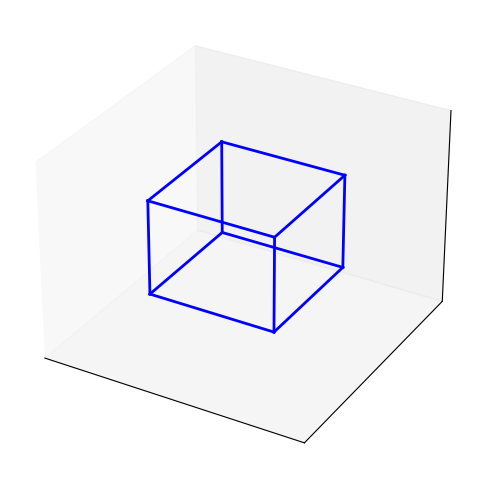

In [13]:
%matplotlib inline

vertices = np.array([
    [-1, -1, -1], [1, -1, -1], [1, 1, -1], [-1, 1, -1],
    [-1, -1, 1], [1, -1, 1], [1, 1, 1], [-1, 1, 1]
])

edges = [
    [0,1], [1,2], [2,3], [3,0],
    [4,5], [5,6], [6,7], [7,4],
    [0,4], [1,5], [2,6], [3,7]
]

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_zlim(-2, 2)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

lines = [ax.plot([], [], [], color='blue', lw=2)[0] for _ in edges]

def rotate(points, angle_x, angle_y, angle_z):
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(angle_x), -np.sin(angle_x)],
        [0, np.sin(angle_x), np.cos(angle_x)]
    ])
    
    Ry = np.array([
        [np.cos(angle_y), 0, np.sin(angle_y)],
        [0, 1, 0],
        [-np.sin(angle_y), 0, np.cos(angle_y)]
    ])
    
    Rz = np.array([
        [np.cos(angle_z), -np.sin(angle_z), 0],
        [np.sin(angle_z), np.cos(angle_z), 0],
        [0, 0, 1]
    ])
    
    return np.dot(points, Rx @ Ry @ Rz)

def update(frame):
    rotated = rotate(vertices, 
                    frame*0.02,  # Угол X
                    frame*0.03,  # Угол Y 
                    frame*0.01)  # Угол Z
    
    for line, (i,j) in zip(lines, edges):
        x = [rotated[i][0], rotated[j][0]]
        y = [rotated[i][1], rotated[j][1]]
        z = [rotated[i][2], rotated[j][2]]
        line.set_data(x, y)
        line.set_3d_properties(z)
    
    return lines

plt.rcParams['animation.convert_path'] = 'convert'

ani = FuncAnimation(fig, update, frames=np.arange(0, 360, 5), interval=50)
ani.save('rotation.gif', writer='imagemagick')
from IPython.display import Image
Image(filename='rotation.gif')

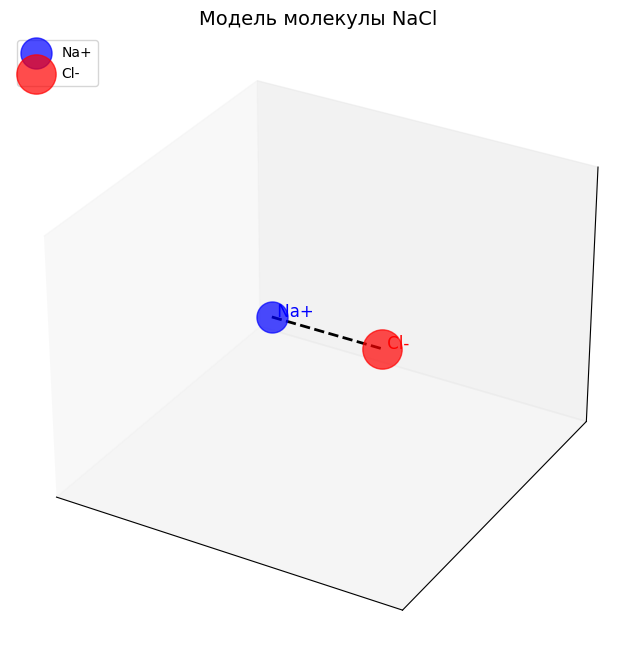

In [14]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

na_pos = [0, 0, 0]
cl_pos = [1, 0, 0]

ax.scatter(*na_pos, s=500, c='blue', alpha=0.7, label='Na+')
ax.scatter(*cl_pos, s=800, c='red', alpha=0.7, label='Cl-')

ax.plot([na_pos[0], cl_pos[0]], 
        [na_pos[1], cl_pos[1]], 
        [na_pos[2], cl_pos[2]], 
        'k--', linewidth=2)

ax.set_title('Модель молекулы NaCl', fontsize=14)
ax.set_xlim(-1, 2)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.legend(loc='upper left')

ax.text(*na_pos, ' Na+', color='blue', fontsize=12)
ax.text(*cl_pos, ' Cl-', color='red', fontsize=12)

plt.show()

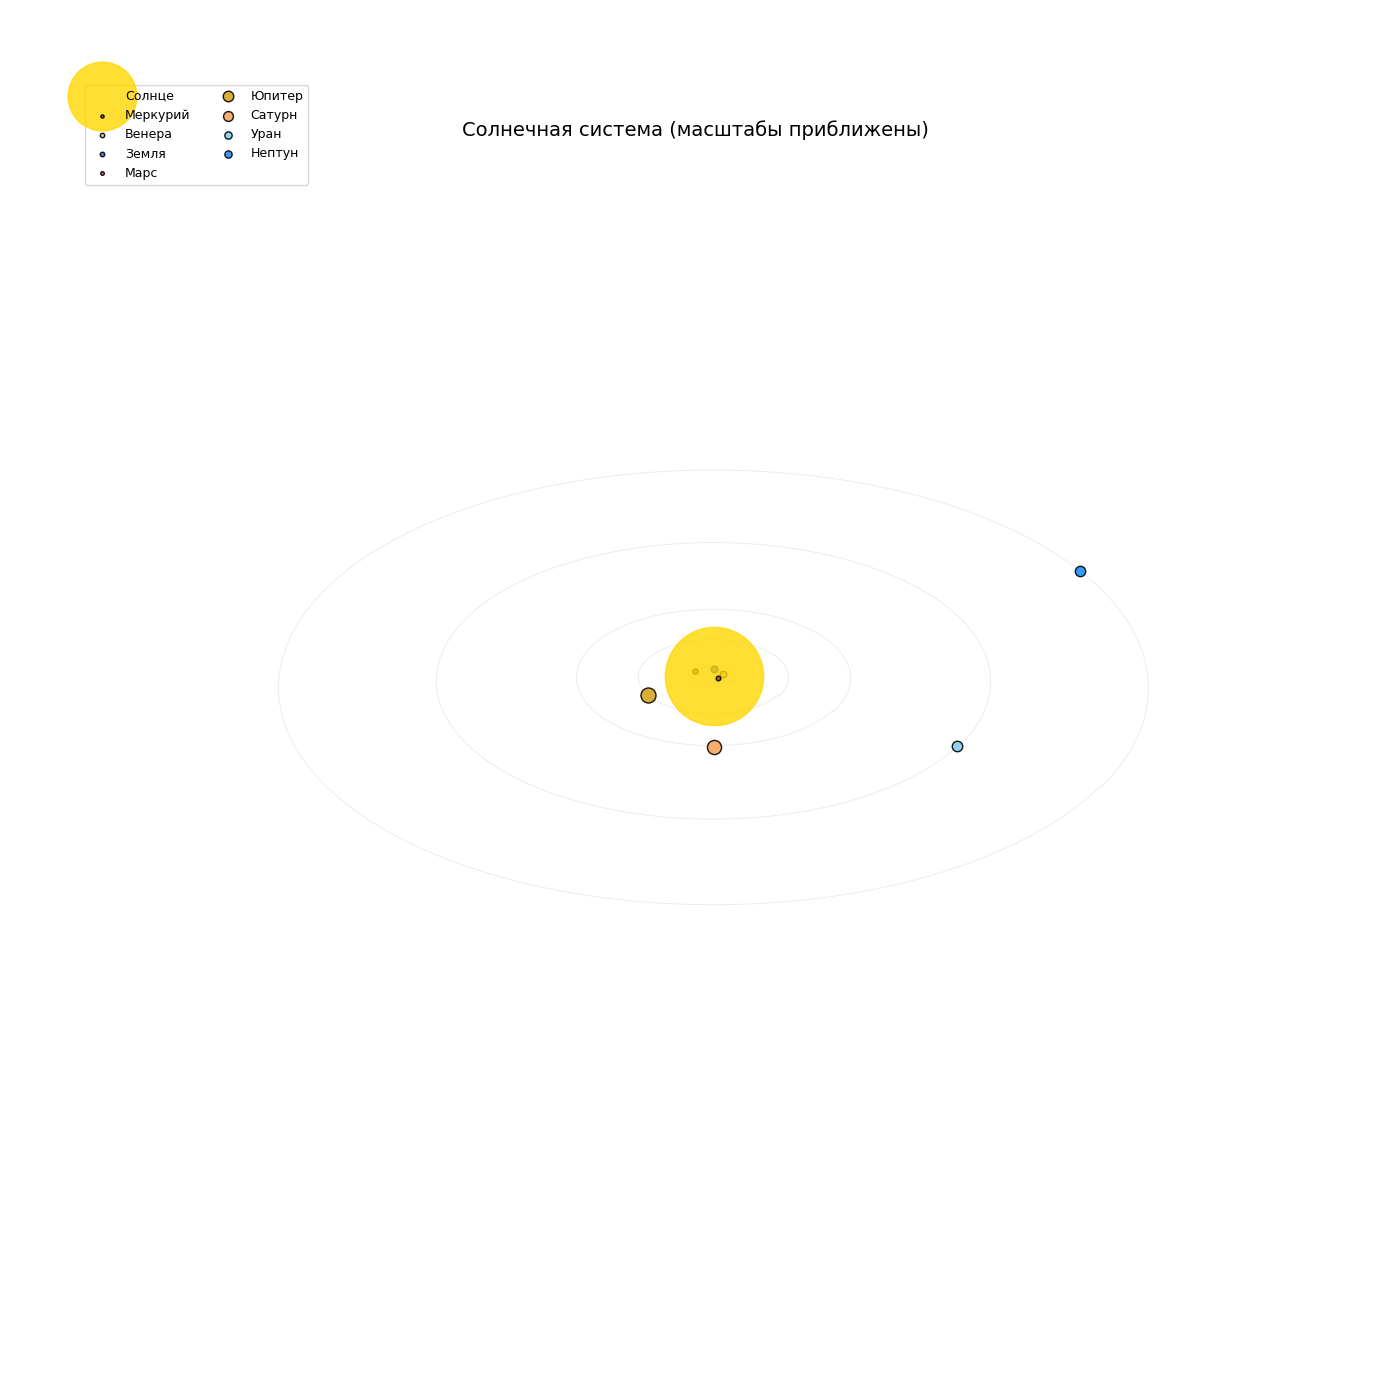

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Реальные относительные размеры планет (диаметры относительно Земли = 1.0)
planet_sizes = np.array([
    0.38,   # Меркурий
    0.95,   # Венера
    1.00,   # Земля
    0.53,   # Марс
    11.2,   # Юпитер
    9.45,   # Сатурн
    4.01,   # Уран
    3.88    # Нептун
])

# Реальные цвета планет (уточненные)
planets = [
    (planet_sizes[0], '#A0522D', 'Меркурий'),    # Темно-коричневый
    (planet_sizes[1], '#DEB887', 'Венера'),       # Светло-коричневый
    (planet_sizes[2], '#4169E1', 'Земля'),        # Королевский синий
    (planet_sizes[3], '#CD5C5C', 'Марс'),         # Индийский красный
    (planet_sizes[4], '#DAA520', 'Юпитер'),       # Золотой
    (planet_sizes[5], '#F4A460', 'Сатурн'),       # Песочный
    (planet_sizes[6], '#87CEEB', 'Уран'),         # Небесно-голубой
    (planet_sizes[7], '#1E90FF', 'Нептун')        # Темно-синий
]

# Реальные орбитальные радиусы (а.е.) с поправкой на масштаб для визуализации
radii = np.array([0.39, 0.72, 1.0, 1.52, 5.2, 9.5, 19.2, 30.1]) * 0.8

# Создаем фигуру с увеличенным DPI для четкости
fig = plt.figure(figsize=(14, 14), dpi=100)
ax = fig.add_subplot(111, projection='3d')

# Солнце (реальный размер был бы ~109 диаметров Земли, уменьшено для визуализации)
ax.scatter([0], [0], [0], s=5000, c='#FFD700', alpha=0.8, label='Солнце')

# Параметры орбит
theta = np.linspace(0, 2*np.pi, 300)

# Рисуем орбиты и планеты
for i, r in enumerate(radii):
    # Орбита (3D спираль для лучшего восприятия глубины)
    z_orbit = np.linspace(-0.1, 0.1, len(theta))  # Небольшой наклон
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    ax.plot(x, y, z_orbit, color='gray', alpha=0.15, lw=0.7)
    
    # Позиция планеты (с учетом 3D-распределения)
    angle = i * np.pi/3  # Начальный угол
    planet_x = r * np.cos(angle)
    planet_y = r * np.sin(angle)
    planet_z = 0.05 * (-1)**i  # Небольшое смещение по Z
    
    # Масштабирование размера для визуализации
    size = (planets[i][0] * 80) ** 0.7
    
    # Визуализация планеты
    ax.scatter(planet_x, planet_y, planet_z,
               s=size,
               c=planets[i][1],
               label=planets[i][2],
               edgecolors='black',
               alpha=0.9,
               depthshade=False)

# Настройки отображения
ax.set_title('Солнечная система (масштабы приближены)', fontsize=14, y=0.98)
ax.set_box_aspect([1,1,0.1])  # Сжатие по оси Z

# Убираем оси и фон
ax.axis('off')
ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Легенда с колонками
ax.legend(ncol=2, loc='upper left', bbox_to_anchor=(0.05, 0.95),
          fontsize=9, markerscale=0.7)

# Динамический диапазон осей
max_radius = radii[-1] * 1.1
ax.set_xlim(-max_radius, max_radius)
ax.set_ylim(-max_radius, max_radius)
ax.set_zlim(-max_radius*0.2, max_radius*0.2)

plt.tight_layout()
plt.show()